# Tarea 3: Polars — Credit Card Fraud Detection
**LEAD University · Prof. Johansell Villalobos Cubillo · 2026**

**Objetivo:** Predecir si una transacción es fraudulenta (`Class = 1`) o legítima (`Class = 0`).

**Dataset:** 284 807 transacciones · 30 variables · Kaggle
https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

---
## 0. Importaciones y configuración

In [ ]:
import sys

import time
import warnings
warnings.filterwarnings("ignore")

import psutil
import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

TARGET = "Class"

# Importaciones para Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import (accuracy_score, f1_score,
                                     roc_auc_score, confusion_matrix,
                                     classification_report)
import xgboost as xgb

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Información del sistema
print(f"CPUs disponibles : {psutil.cpu_count(logical=True)}")
print(f"RAM total : {psutil.virtual_memory().total / 1e9:.1f} GB")
print(f"Polars : {pl.__version__}")
print(f"Pandas : {pd.__version__}")

# Ruta al CSV de Kaggle 
RUTA_CSV = "../data/raw/creditcard.csv"

---
## 1. Análisis Exploratorio con Polars

In [3]:
# Celda — Cargar el dataset
t0 = time.perf_counter()

df = pl.read_csv(RUTA_CSV, infer_schema_length=0)  # infer_schema_length=0 lee TODO como String primero

# Convertir columnas numéricas al tipo correcto
df = df.with_columns(
    [pl.col(c).cast(pl.Float64, strict=False) for c in df.columns]
)

t_lectura = time.perf_counter() - t0

print(f"✓ Dataset cargado en {t_lectura:.3f}s")
print(f"  Filas    : {len(df):,}")
print(f"  Columnas : {df.width}")
print(f"  Nombres  : {df.columns}")

✓ Dataset cargado en 0.269s
  Filas    : 284,807
  Columnas : 31
  Nombres  : ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


### 1.1 Estadísticas descriptivas

In [4]:
# Mostramos solo las columnas más relevantes para no saturar la pantalla
print(df.select(["Time", "Amount", TARGET]).describe())

shape: (9, 4)
┌────────────┬──────────────┬────────────┬──────────┐
│ statistic  ┆ Time         ┆ Amount     ┆ Class    │
│ ---        ┆ ---          ┆ ---        ┆ ---      │
│ str        ┆ f64          ┆ f64        ┆ f64      │
╞════════════╪══════════════╪════════════╪══════════╡
│ count      ┆ 284807.0     ┆ 284807.0   ┆ 284807.0 │
│ null_count ┆ 0.0          ┆ 0.0        ┆ 0.0      │
│ mean       ┆ 94813.859575 ┆ 88.349619  ┆ 0.001727 │
│ std        ┆ 47488.145955 ┆ 250.120109 ┆ 0.041527 │
│ min        ┆ 0.0          ┆ 0.0        ┆ 0.0      │
│ 25%        ┆ 54202.0      ┆ 5.6        ┆ 0.0      │
│ 50%        ┆ 84692.0      ┆ 22.0       ┆ 0.0      │
│ 75%        ┆ 139321.0     ┆ 77.17      ┆ 0.0      │
│ max        ┆ 172792.0     ┆ 25691.16   ┆ 1.0      │
└────────────┴──────────────┴────────────┴──────────┘


### 1.2 Valores faltantes

In [7]:
# 1.2 Valores faltantes
nulos = df.null_count()
total_nulos = sum(nulos.row(0))

if total_nulos == 0:
    print("El dataset no tiene valores faltantes.")
else:
    print("Columnas con nulos:")
    print(nulos)

El dataset no tiene valores faltantes.


### 1.3 Distribución de la variable objetivo

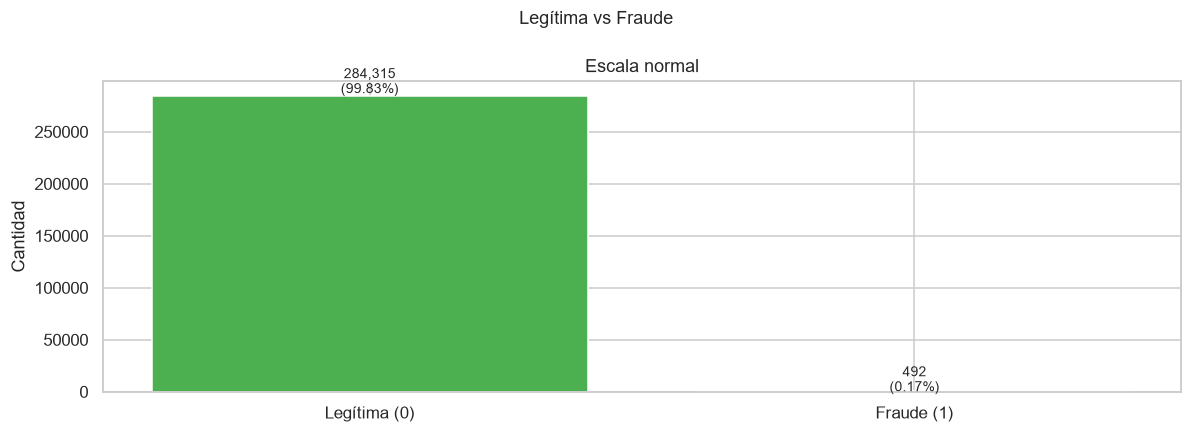

In [18]:
# 1.3 Distribución de clases
distribucion = (
    df
    .group_by(TARGET)
    .agg(pl.len().alias("cantidad"))
    .sort(TARGET)
)

cantidades = distribucion["cantidad"].to_list()
etiquetas  = ["Legítima (0)", "Fraude (1)"]

# Dos gráficas: normal y logarítmica
fig, ejes = plt.subplots( figsize=(11, 4))

# Izquierda — escala normal
ejes.bar(etiquetas, cantidades, color=["#4CAF50", "#F44336"])
ejes.set_title("Escala normal")
ejes.set_ylabel("Cantidad")
for i, v in enumerate(cantidades):
    ejes.text(i, v * 1.01, f"{v:,}\n({v/len(df):.2%})",
                 ha="center", fontsize=9)

plt.suptitle("Legítima vs Fraude", fontsize=12)
plt.tight_layout()
plt.savefig("../figures/distribucion_clases.png", dpi=150, bbox_inches="tight")
plt.show()

### 1.4 Distribución del monto de transacciones

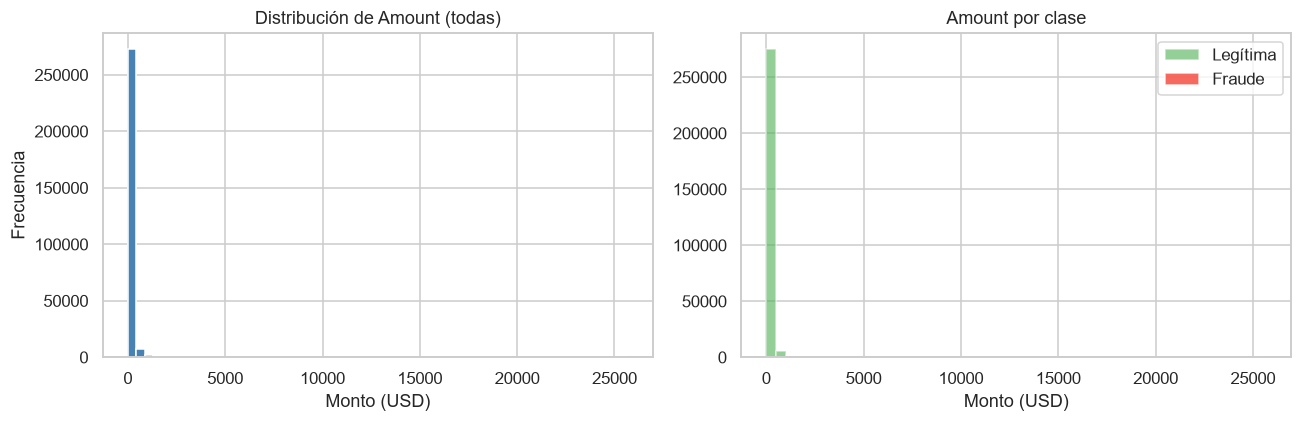

In [22]:
# 1.4 Distribución del monto (Amount)
amounts_legitimas = df.filter(pl.col(TARGET) == 0)["Amount"].to_list()
amounts_fraudes   = df.filter(pl.col(TARGET) == 1)["Amount"].to_list()

fig, ejes = plt.subplots(1, 2, figsize=(12, 4))

# Izquierda: todas las transacciones
ejes[0].hist(df["Amount"].to_list(), bins=60, color="steelblue", edgecolor="white")
ejes[0].set_title("Distribución de Amount (todas)")
ejes[0].set_xlabel("Monto (USD)")
ejes[0].set_ylabel("Frecuencia")

# Derecha: separado por clase
ejes[1].hist(amounts_legitimas, bins=50, alpha=0.6, color="#4CAF50",
             label="Legítima", edgecolor="white")
ejes[1].hist(amounts_fraudes, bins=50, alpha=0.8, color="#F44336",
             label="Fraude", edgecolor="white")
ejes[1].set_title("Amount por clase")
ejes[1].set_xlabel("Monto (USD)")
ejes[1].legend()

plt.tight_layout()
plt.savefig("../figures/distribucion_amount.png", dpi=150, bbox_inches="tight")
plt.show()

### 1.5 Tasa de fraude por hora del día (group_by en EDA)

shape: (24, 3)
┌──────┬────────────┬───────┐
│ Hora ┆ pct_fraude ┆ total │
│ ---  ┆ ---        ┆ ---   │
│ i64  ┆ f64        ┆ u32   │
╞══════╪════════════╪═══════╡
│ 0    ┆ 0.08       ┆ 7695  │
│ 1    ┆ 0.24       ┆ 4220  │
│ 2    ┆ 1.71       ┆ 3328  │
│ 3    ┆ 0.49       ┆ 3492  │
│ 4    ┆ 1.04       ┆ 2209  │
│ …    ┆ …          ┆ …     │
│ 19   ┆ 0.12       ┆ 15649 │
│ 20   ┆ 0.11       ┆ 16756 │
│ 21   ┆ 0.09       ┆ 17703 │
│ 22   ┆ 0.06       ┆ 15441 │
│ 23   ┆ 0.19       ┆ 10938 │
└──────┴────────────┴───────┘


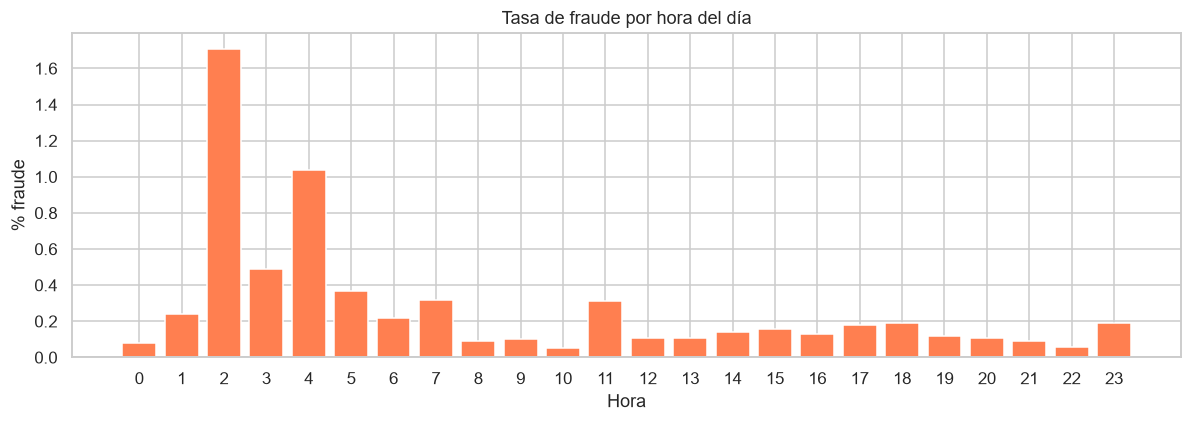

In [24]:
# 1.5 Tasa de fraude por hora del día
fraude_hora = (
    df
    .with_columns(
        (pl.col("Time").cast(pl.Int64) // 3600 % 24).alias("Hora")
    )
    .group_by("Hora")
    .agg(
        (pl.col(TARGET).cast(pl.Float64).mean() * 100).round(2).alias("pct_fraude"),
        pl.len().alias("total")
    )
    .sort("Hora")
)
print(fraude_hora)

# Extraer sin .to_pandas()
horas      = fraude_hora["Hora"].to_list()
pct_fraude = fraude_hora["pct_fraude"].to_list()

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(horas, pct_fraude, color="coral")
ax.set_title("Tasa de fraude por hora del día")
ax.set_xlabel("Hora")
ax.set_ylabel("% fraude")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig("../figures/fraude_por_hora.png", dpi=150, bbox_inches="tight")
plt.show()

### 1.6 Correlación de variables con la clase objetivo

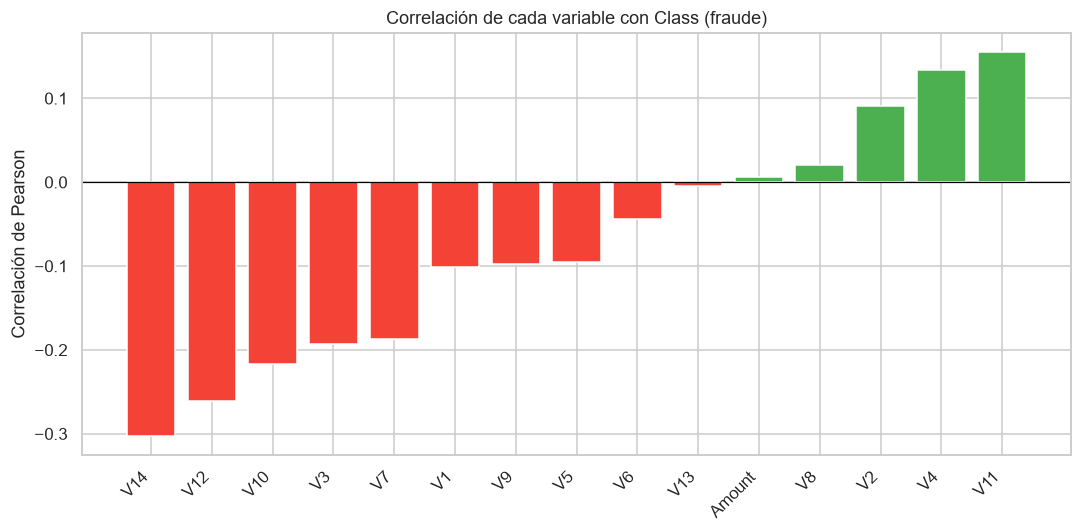

In [28]:
# 1.6 Correlación de variables con Class
cols_corr = [f"V{i}" for i in range(1, 15)] + ["Amount"]

# Calculamos correlación con numpy (sin pyarrow)
target_vals = np.array(df[TARGET].to_list())

corr_values = []
for col in cols_corr:
    col_vals = np.array(df[col].to_list())
    c = np.corrcoef(col_vals, target_vals)[0, 1]
    corr_values.append((col, round(c, 4)))

# Ordenar por valor
corr_values.sort(key=lambda x: x[1])
nombres = [x[0] for x in corr_values]
valores = [x[1] for x in corr_values]

# Gráfica
fig, ax = plt.subplots(figsize=(10, 5))
colores = ["#F44336" if v < 0 else "#4CAF50" for v in valores]
ax.bar(nombres, valores, color=colores)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Correlación de cada variable con Class (fraude)")
ax.set_ylabel("Correlación de Pearson")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../figures/correlacion.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 2. Ingeniería de Características con Polars

In [36]:
# PARTE 2: INGENIERÍA DE CARACTERÍSTICAS 

# 2.1 Crear nuevas columnas
df = df.with_columns([
    # Hora del día (extraída de Time)
    (pl.col("Time").cast(pl.Int64) // 3600 % 24).alias("Hora"),
    # Log del monto (reduce el sesgo de valores muy grandes)
    (pl.col("Amount") + 1).log(base=10).alias("Amount_log"),
])

print("✓ Nuevas columnas creadas: Hora, Amount_log")
print(df.select(["Time", "Hora", "Amount", "Amount_log"]).head(5))

✓ Nuevas columnas creadas: Hora, Amount_log
shape: (5, 4)
┌──────┬──────┬────────┬────────────┐
│ Time ┆ Hora ┆ Amount ┆ Amount_log │
│ ---  ┆ ---  ┆ ---    ┆ ---        │
│ f64  ┆ i64  ┆ f64    ┆ f64        │
╞══════╪══════╪════════╪════════════╡
│ 0.0  ┆ 0    ┆ 149.62 ┆ 2.177883   │
│ 0.0  ┆ 0    ┆ 2.69   ┆ 0.567026   │
│ 1.0  ┆ 0    ┆ 378.66 ┆ 2.579395   │
│ 1.0  ┆ 0    ┆ 123.5  ┆ 2.095169   │
│ 2.0  ┆ 0    ┆ 69.99  ┆ 1.851197   │
└──────┴──────┴────────┴────────────┘


In [31]:
# 2.2 group_by + join: tasa de fraude promedio por hora
# Esto crea una nueva columna que dice "en esta hora del día,
# históricamente X% de las transacciones son fraude"

tasa_por_hora = (
    df
    .group_by("Hora")
    .agg(
        pl.col(TARGET).cast(pl.Float64).mean().alias("fraude_tasa_hora")
    )
)

# Join: agregar esa tasa al dataframe principal
df = df.join(tasa_por_hora, on="Hora", how="left")

print("✓ Join completado")
print(df.select(["Hora", "fraude_tasa_hora", TARGET]).head(5))

✓ Join completado
shape: (5, 3)
┌──────┬──────────────────┬───────┐
│ Hora ┆ fraude_tasa_hora ┆ Class │
│ ---  ┆ ---              ┆ ---   │
│ i64  ┆ f64              ┆ f64   │
╞══════╪══════════════════╪═══════╡
│ 0    ┆ 0.00078          ┆ 0.0   │
│ 0    ┆ 0.00078          ┆ 0.0   │
│ 0    ┆ 0.00078          ┆ 0.0   │
│ 0    ┆ 0.00078          ┆ 0.0   │
│ 0    ┆ 0.00078          ┆ 0.0   │
└──────┴──────────────────┴───────┘


In [32]:
# 2.3 Filtrado: eliminar filas sin etiqueta y montos negativos
filas_antes = len(df)

df = (
    df
    .filter(pl.col(TARGET).is_not_null())
    .filter(pl.col("Amount") >= 0)
)

filas_despues = len(df)

print(f"Filas antes  : {filas_antes:,}")
print(f"Filas después: {filas_despues:,}")
print(f"Eliminadas   : {filas_antes - filas_despues:,}")

Filas antes  : 284,807
Filas después: 284,807
Eliminadas   : 0


In [33]:
# 2.4 Manejo de nulos
# Ya vimos en 1.2 que no hay nulos, pero lo documentamos igual
nulos_antes = sum(df.null_count().row(0))

# Por si acaso: imputar Amount y Time con mediana, V1-V28 con 0
cols_v = [f"V{i}" for i in range(1, 29)]

df = df.with_columns(
    [pl.col("Amount").fill_null(df["Amount"].median()),
     pl.col("Time").fill_null(df["Time"].median())]
    + [pl.col(v).fill_null(0.0) for v in cols_v]
)

nulos_despues = sum(df.null_count().row(0))

print(f"Nulos antes  : {nulos_antes}")
print(f"Nulos después: {nulos_despues}")
print("✓ Dataset listo para Machine Learning")
print(f"  Filas: {len(df):,}  |  Columnas: {df.width}")

Nulos antes  : 0
Nulos después: 0
✓ Dataset listo para Machine Learning
  Filas: 284,807  |  Columnas: 34


---
## 3. Machine Learning

In [37]:
# PARTE 3: MACHINE LEARNING 

# 3.1 Preparar X e y
# Features: todas las V1-V28 + Amount_log + Hora + fraude_tasa_hora
features = [f"V{i}" for i in range(1, 29)] + ["Amount_log", "Hora", "fraude_tasa_hora"]

X = np.array(df.select(features).to_numpy(), dtype=float)
y = np.array(df[TARGET].to_list(), dtype=int)

# Split 80% entrenamiento / 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalado
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"✓ Datos listos")
print(f"  Train : {X_train.shape[0]:,} muestras")
print(f"  Test  : {X_test.shape[0]:,} muestras")
print(f"  Fraudes en train: {y_train.sum():,} ({y_train.mean():.3%})")

✓ Datos listos
  Train : 227,845 muestras
  Test  : 56,962 muestras
  Fraudes en train: 394 (0.173%)


In [41]:
# 3.2 Modelo 1 — Regresión Logística
t0 = time.perf_counter()

modelo_lr = LogisticRegression(
    max_iter=500,
    class_weight="balanced",  # compensa el desbalance
    random_state=42,
    n_jobs=-1
)
modelo_lr.fit(X_train, y_train)

t_lr = time.perf_counter() - t0
print(f"Regresión Logística entrenada en {t_lr:.2f}s")

# Evaluación
y_pred_lr = modelo_lr.predict(X_test)
y_prob_lr = modelo_lr.predict_proba(X_test)[:, 1]

print(f"  Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"  F1       : {f1_score(y_test, y_pred_lr):.4f}")
print(f"  AUC-ROC  : {roc_auc_score(y_test, y_prob_lr):.4f}")
print(classification_report(y_test, y_pred_lr,
      target_names=["Legítima", "Fraude"], zero_division=0))

Regresión Logística entrenada en 1.22s
  Accuracy : 0.9729
  F1       : 0.1035
  AUC-ROC  : 0.9707
              precision    recall  f1-score   support

    Legítima       1.00      0.97      0.99     56864
      Fraude       0.05      0.91      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.54     56962
weighted avg       1.00      0.97      0.98     56962



In [40]:
# 3.3 Modelo 2 — Random Forest
t0 = time.perf_counter()

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",  # compensa el desbalance
    random_state=42,
    n_jobs=-1
)
modelo_rf.fit(X_train, y_train)

t_rf = time.perf_counter() - t0
print(f"✓ Random Forest entrenado en {t_rf:.2f}s")

# Evaluación
y_pred_rf = modelo_rf.predict(X_test)
y_prob_rf = modelo_rf.predict_proba(X_test)[:, 1]

print(f"  Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  F1       : {f1_score(y_test, y_pred_rf):.4f}")
print(f"  AUC-ROC  : {roc_auc_score(y_test, y_prob_rf):.4f}")
print(classification_report(y_test, y_pred_rf,
      target_names=["Legítima", "Fraude"], zero_division=0))

✓ Random Forest entrenado en 25.93s
  Accuracy : 0.9989
  F1       : 0.7193
  AUC-ROC  : 0.9770
              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00     56864
      Fraude       0.63      0.84      0.72        98

    accuracy                           1.00     56962
   macro avg       0.82      0.92      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [42]:
# 3.4 Modelo 3 — XGBoost
t0 = time.perf_counter()

# scale_pos_weight compensa el desbalance: legitimas / fraudes
ratio = (y_train == 0).sum() / (y_train == 1).sum()

modelo_xgb = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=ratio,  # compensa el desbalance
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
    verbosity=0
)
modelo_xgb.fit(X_train, y_train)

t_xgb = time.perf_counter() - t0
print(f"✓ XGBoost entrenado en {t_xgb:.2f}s")

# Evaluación
y_pred_xgb = modelo_xgb.predict(X_test)
y_prob_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

print(f"  Accuracy : {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"  F1       : {f1_score(y_test, y_pred_xgb):.4f}")
print(f"  AUC-ROC  : {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb,
      target_names=["Legítima", "Fraude"], zero_division=0))

✓ XGBoost entrenado en 5.57s
  Accuracy : 0.9995
  F1       : 0.8646
  AUC-ROC  : 0.9727
              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00     56864
      Fraude       0.88      0.85      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



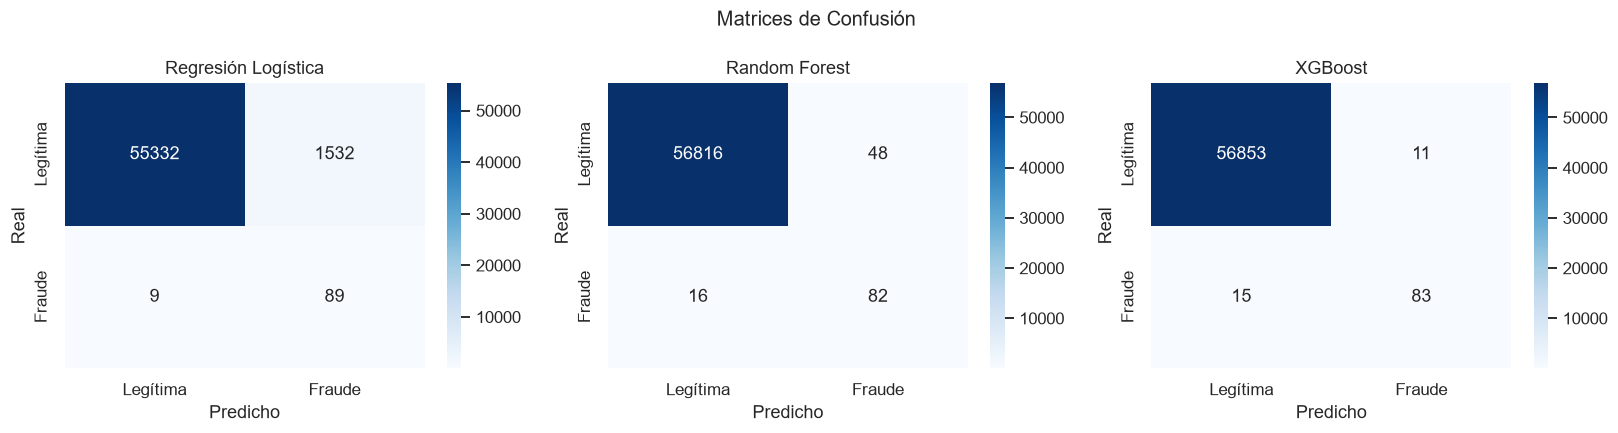

In [43]:
# 3.5 Matrices de confusión de los 3 modelos
fig, ejes = plt.subplots(1, 3, figsize=(15, 4))

modelos = [
    ("Regresión Logística", confusion_matrix(y_test, y_pred_lr)),
    ("Random Forest",       confusion_matrix(y_test, y_pred_rf)),
    ("XGBoost",             confusion_matrix(y_test, y_pred_xgb)),
]

for ax, (nombre, cm) in zip(ejes, modelos):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Legítima", "Fraude"],
                yticklabels=["Legítima", "Fraude"], ax=ax)
    ax.set_title(nombre)
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")

plt.suptitle("Matrices de Confusión", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/matrices_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

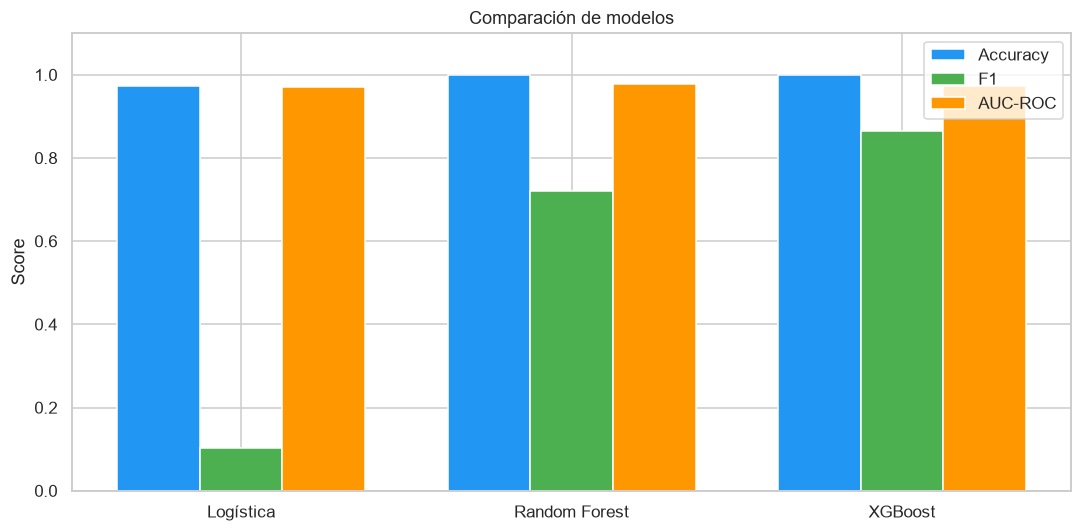


=== Resultados de Machine Learning ===
Modelo               Accuracy       F1    AUC-ROC  Tiempo(s)
----------------------------------------------------------
Logística              0.9729   0.1035     0.9707       1.22
Random Forest          0.9989   0.7193     0.9770      25.93
XGBoost                0.9995   0.8646     0.9727       5.57

✓ Guardado en results/resultados_modelos.csv


In [44]:
# 3.6 Comparación de modelos y tabla resumen

# Datos de los 3 modelos
resultados = [
    {"nombre": "Logística",     "accuracy": accuracy_score(y_test, y_pred_lr),
     "f1": f1_score(y_test, y_pred_lr), "auc": roc_auc_score(y_test, y_prob_lr),
     "tiempo": t_lr},
    {"nombre": "Random Forest", "accuracy": accuracy_score(y_test, y_pred_rf),
     "f1": f1_score(y_test, y_pred_rf), "auc": roc_auc_score(y_test, y_prob_rf),
     "tiempo": t_rf},
    {"nombre": "XGBoost",       "accuracy": accuracy_score(y_test, y_pred_xgb),
     "f1": f1_score(y_test, y_pred_xgb), "auc": roc_auc_score(y_test, y_prob_xgb),
     "tiempo": t_xgb},
]

# Gráfica comparación
nombres  = [r["nombre"] for r in resultados]
accuracy = [r["accuracy"] for r in resultados]
f1       = [r["f1"]       for r in resultados]
auc      = [r["auc"]      for r in resultados]

x, ancho = np.arange(3), 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - ancho, accuracy, ancho, label="Accuracy", color="#2196F3")
ax.bar(x,         f1,       ancho, label="F1",       color="#4CAF50")
ax.bar(x + ancho, auc,      ancho, label="AUC-ROC",  color="#FF9800")
ax.set_xticks(x)
ax.set_xticklabels(nombres)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Comparación de modelos")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/comparacion_modelos.png", dpi=150, bbox_inches="tight")
plt.show()

# Tabla resumen
print("\n=== Resultados de Machine Learning ===")
print(f"{'Modelo':<18} {'Accuracy':>10} {'F1':>8} {'AUC-ROC':>10} {'Tiempo(s)':>10}")
print("-" * 58)
for r in resultados:
    print(f"{r['nombre']:<18} {r['accuracy']:>10.4f} {r['f1']:>8.4f} "
          f"{r['auc']:>10.4f} {r['tiempo']:>10.2f}")

# Guardar en CSV
import csv
with open("../results/resultados_modelos.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["nombre","accuracy","f1","auc","tiempo"])
    writer.writeheader()
    writer.writerows(resultados)
print("\n✓ Guardado en results/resultados_modelos.csv")


## 4. Benchmark: Polars vs Pandas

In [ ]:
# PARTE 4: BENCHMARK POLARS VS PANDAS

# 4.1 Pipeline con Polars (ya lo hicimos, solo medimos los tiempos)
print("Midiendo tiempos con Polars...")

t0 = time.perf_counter()
df_pl = pl.read_csv("../data/raw/creditcard.csv", infer_schema_length=0)
df_pl = df_pl.with_columns(
    [pl.col(c).cast(pl.Float64, strict=False) for c in df_pl.columns]
)
t_pl_lectura = time.perf_counter() - t0

t0 = time.perf_counter()
df_pl = df_pl.filter(pl.col(TARGET).is_not_null()).filter(pl.col("Amount") >= 0)
t_pl_filtrado = time.perf_counter() - t0

t0 = time.perf_counter()
df_pl = df_pl.with_columns([
    (pl.col("Time").cast(pl.Int64) // 3600 % 24).alias("Hora"),
    (pl.col("Amount") + 1).log(base=10).alias("Amount_log"),
])
tasa = df_pl.group_by("Hora").agg(
    pl.col(TARGET).cast(pl.Float64).mean().alias("fraude_tasa_hora")
)
df_pl = df_pl.join(tasa, on="Hora", how="left")
t_pl_features = time.perf_counter() - t0

t_pl_total = t_pl_lectura + t_pl_filtrado + t_pl_features
print(f"  Lectura  : {t_pl_lectura:.3f}s")
print(f"  Filtrado : {t_pl_filtrado:.3f}s")
print(f"  Features : {t_pl_features:.3f}s")
print(f"  TOTAL    : {t_pl_total:.3f}s")

Midiendo tiempos con Polars...
  Lectura  : 0.325s
  Filtrado : 0.012s
  Features : 0.020s
  TOTAL    : 0.357s


In [46]:
# 4.2 Pipeline con Pandas (mismo proceso)
print("Midiendo tiempos con Pandas...")

t0 = time.perf_counter()
df_pd = pd.read_csv("../data/raw/creditcard.csv")
t_pd_lectura = time.perf_counter() - t0

t0 = time.perf_counter()
df_pd = df_pd[df_pd[TARGET].notna() & (df_pd["Amount"] >= 0)].copy()
t_pd_filtrado = time.perf_counter() - t0

t0 = time.perf_counter()
df_pd["Hora"]       = (df_pd["Time"].astype(int) // 3600 % 24)
df_pd["Amount_log"] = np.log10(df_pd["Amount"] + 1)
tasa_pd = df_pd.groupby("Hora")[TARGET].mean().reset_index()
tasa_pd.columns = ["Hora", "fraude_tasa_hora"]
df_pd = df_pd.merge(tasa_pd, on="Hora", how="left")
t_pd_features = time.perf_counter() - t0

t_pd_total = t_pd_lectura + t_pd_filtrado + t_pd_features
print(f"  Lectura  : {t_pd_lectura:.3f}s")
print(f"  Filtrado : {t_pd_filtrado:.3f}s")
print(f"  Features : {t_pd_features:.3f}s")
print(f"  TOTAL    : {t_pd_total:.3f}s")

Midiendo tiempos con Pandas...
  Lectura  : 2.630s
  Filtrado : 0.097s
  Features : 0.062s
  TOTAL    : 2.789s


In [47]:
# 4.3 Tabla comparativa y gráficas
etapas  = ["Lectura", "Filtrado", "Features", "TOTAL"]
t_polars = [t_pl_lectura, t_pl_filtrado, t_pl_features, t_pl_total]
t_pandas = [t_pd_lectura, t_pd_filtrado, t_pd_features, t_pd_total]
speedup  = [round(tp/tpl, 2) if tpl > 0 else 0
            for tp, tpl in zip(t_pandas, t_polars)]

# Tabla
benchmark = pd.DataFrame({
    "Etapa"     : etapas,
    "Polars (s)": [round(t, 4) for t in t_polars],
    "Pandas (s)": [round(t, 4) for t in t_pandas],
    "Speedup"   : speedup,
})
print("=== Benchmark Polars vs Pandas ===")
display(benchmark)
benchmark.to_csv("../results/benchmark.csv", index=False)

=== Benchmark Polars vs Pandas ===


,Etapa,Polars (s),Pandas (s),Speedup
0,Lectura,0.3248,2.6298,8.10
1,Filtrado,0.0123,0.0972,7.88
2,Features,0.0202,0.0621,3.08
3,TOTAL,0.3573,2.7891,7.81


### 4.1 Gráfica de tiempos

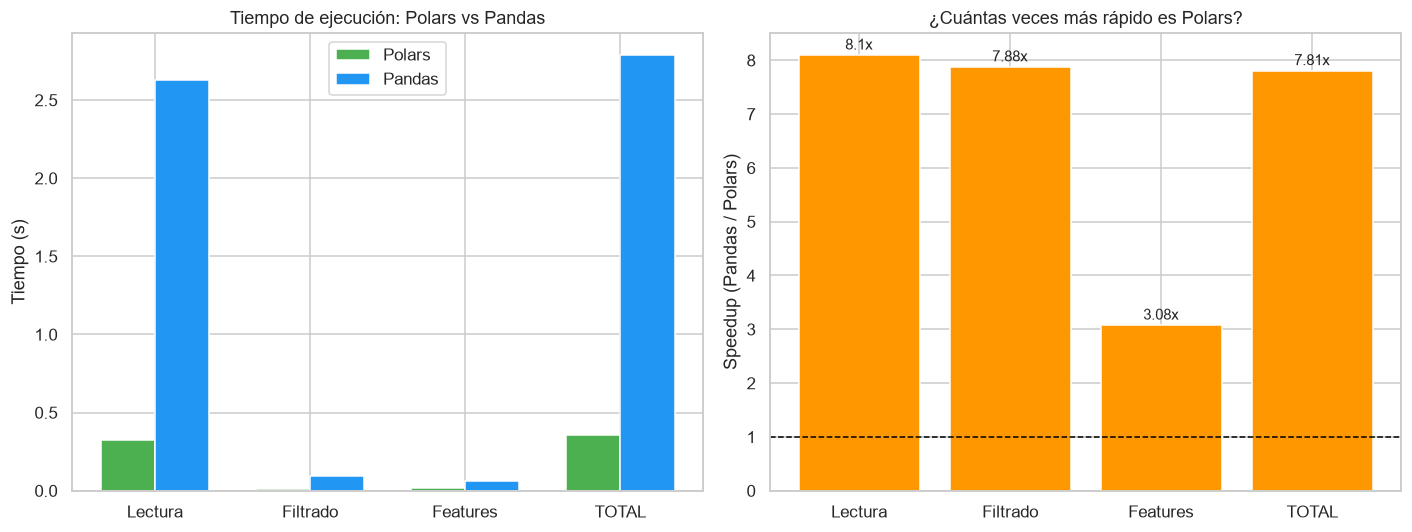

In [49]:
# 4.4 Gráficas del benchmark
fig, ejes = plt.subplots(1, 2, figsize=(13, 5))

x, ancho = np.arange(len(etapas)), 0.35

# Izquierda — tiempos
ejes[0].bar(x - ancho/2, t_polars, ancho, label="Polars", color="#4CAF50")
ejes[0].bar(x + ancho/2, t_pandas, ancho, label="Pandas", color="#2196F3")
ejes[0].set_xticks(x)
ejes[0].set_xticklabels(etapas)
ejes[0].set_ylabel("Tiempo (s)")
ejes[0].set_title("Tiempo de ejecución: Polars vs Pandas")
ejes[0].legend()

# Derecha — speedup
colores = ["#FF9800" if s >= 1 else "#F44336" for s in speedup]
ejes[1].bar(etapas, speedup, color=colores)
ejes[1].axhline(1, color="black", linestyle="--", linewidth=1)
ejes[1].set_ylabel("Speedup (Pandas / Polars)")
ejes[1].set_title("¿Cuántas veces más rápido es Polars?")
for i, s in enumerate(speedup):
    ejes[1].text(i, s + 0.1, f"{s}x", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("../figures/benchmark.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5. Experimento 1: Escalabilidad (25 / 50 / 75 / 100 %)

In [51]:
# PARTE 5: EXPERIMENTO 1 — ESCALABILIDAD

import os
os.makedirs("../data/processed", exist_ok=True)

fracciones   = [0.25, 0.50, 0.75, 1.00]
n_total      = len(df_pd)
filas_escala = []

for frac in fracciones:
    n   = int(n_total * frac)
    idx = np.random.RandomState(42).choice(n_total, n, replace=False)
    sub = df_pd.iloc[idx].reset_index(drop=True)

    # Guardar subconjunto en carpeta local (no /tmp/)
    ruta_sub = "../data/processed/sub_temp.csv"
    sub.to_csv(ruta_sub, index=False)

    # Tiempo Pandas
    t0 = time.perf_counter()
    pd.read_csv(ruta_sub)
    t_pan = time.perf_counter() - t0

    # Tiempo Polars
    t0 = time.perf_counter()
    pl.read_csv(ruta_sub)
    t_pol = time.perf_counter() - t0

    sp = round(t_pan / t_pol, 2) if t_pol > 0 else 0
    filas_escala.append({
        "Fracción"  : f"{int(frac*100)}%",
        "Filas"     : n,
        "Pandas (s)": round(t_pan, 4),
        "Polars (s)": round(t_pol, 4),
        "Speedup"   : sp,
    })
    print(f"  {int(frac*100):3d}%  ({n:,} filas) → "
          f"Pandas {t_pan:.3f}s | Polars {t_pol:.3f}s | {sp:.2f}x")

# Tabla
escala_df = pd.DataFrame(filas_escala)
display(escala_df)
escala_df.to_csv("../results/escalabilidad.csv", index=False)

   25%  (71,201 filas) → Pandas 0.745s | Polars 0.059s | 12.73x
   50%  (142,403 filas) → Pandas 1.543s | Polars 0.105s | 14.70x
   75%  (213,605 filas) → Pandas 2.433s | Polars 0.156s | 15.64x
  100%  (284,807 filas) → Pandas 3.216s | Polars 0.192s | 16.78x


,Fracción,Filas,Pandas (s),Polars (s),Speedup
0,25%,71201,0.7452,0.0585,12.73
1,50%,142403,1.5432,0.1050,14.70
2,75%,213605,2.4327,0.1555,15.64
3,100%,284807,3.2164,0.1917,16.78


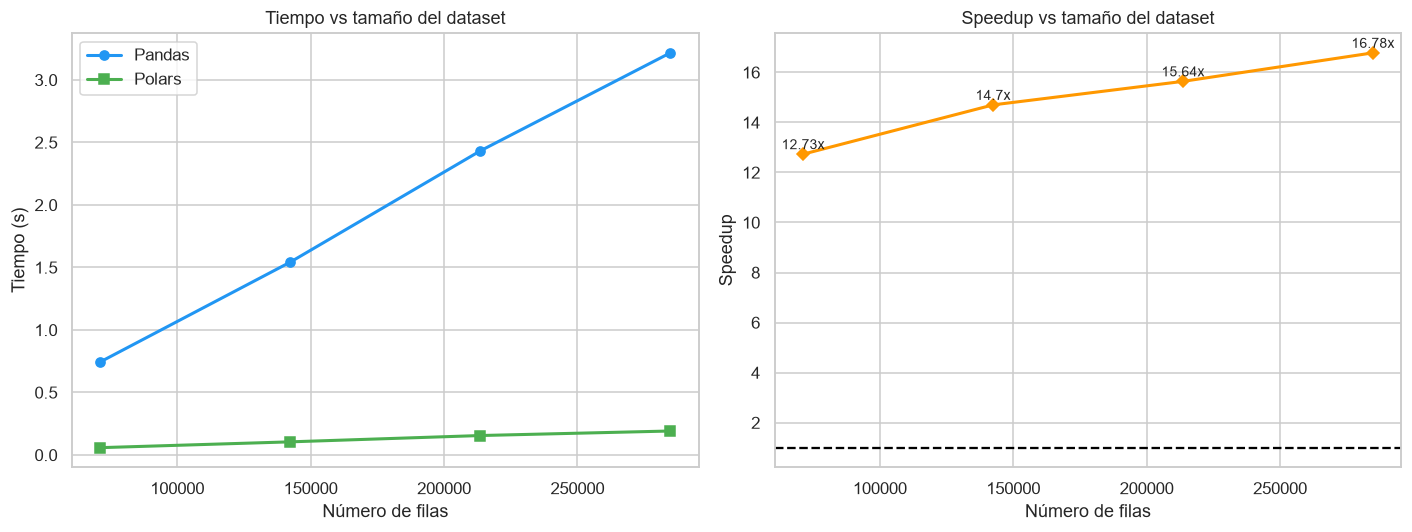

In [53]:
# Gráfica de escalabilidad
filas   = [r["Filas"]      for r in filas_escala]
t_pan_e = [r["Pandas (s)"] for r in filas_escala]
t_pol_e = [r["Polars (s)"] for r in filas_escala]
sp_e    = [r["Speedup"]    for r in filas_escala]

fig, ejes = plt.subplots(1, 2, figsize=(13, 5))

# Izquierda — tiempos
ejes[0].plot(filas, t_pan_e, "o-", label="Pandas", color="#2196F3", linewidth=2)
ejes[0].plot(filas, t_pol_e, "s-", label="Polars", color="#4CAF50", linewidth=2)
ejes[0].set_xlabel("Número de filas")
ejes[0].set_ylabel("Tiempo (s)")
ejes[0].set_title("Tiempo vs tamaño del dataset")
ejes[0].legend()

# Derecha — speedup
ejes[1].plot(filas, sp_e, "D-", color="#FF9800", linewidth=2)
ejes[1].axhline(1, color="black", linestyle="--")
ejes[1].set_xlabel("Número de filas")
ejes[1].set_ylabel("Speedup")
ejes[1].set_title("Speedup vs tamaño del dataset")
for i, (f, s) in enumerate(zip(filas, sp_e)):
    ejes[1].text(f, s + 0.2, f"{s}x", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../figures/escalabilidad.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 6. Experimento 2: Lazy Execution vs Eager

In [ ]:
# PARTE 6: EXPERIMENTO 2 LAZY VS EAGER

print("Comparando Eager vs Lazy (3 repeticiones)...\n")

tiempos_eager = []
tiempos_lazy  = []

for i in range(3):
    t0 = time.perf_counter()
    pl.read_csv(RUTA_CSV, infer_schema_length=0)
    tiempos_eager.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    pl.scan_csv(RUTA_CSV, infer_schema_length=0).collect()
    tiempos_lazy.append(time.perf_counter() - t0)

mean_eager = round(np.mean(tiempos_eager), 3)
mean_lazy  = round(np.mean(tiempos_lazy),  3)

print(f"Eager (read_csv)         : {mean_eager}s")
print(f"Lazy  (scan_csv+collect) : {mean_lazy}s")

# Gráfica limpia sin barras de error
fig, ax = plt.subplots(figsize=(6, 5))
barras = ax.bar(
    ["Eager\n(read_csv)", "Lazy\n(scan_csv + collect)"],
    [mean_eager, mean_lazy],
    color=["#3F51B5", "#009688"],
    width=0.4
)
ax.set_ylabel("Tiempo promedio (s)")
ax.set_title("Eager vs Lazy Execution")
ax.set_ylim(0, max(mean_eager, mean_lazy) * 1.3)

# Etiquetas encima de cada barra
for barra, v in zip(barras, [mean_eager, mean_lazy]):
    ax.text(barra.get_x() + barra.get_width()/2,
            barra.get_height() + 0.005,
            f"{v}s", ha="center", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("../figures/lazy_vs_eager.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7. Análisis de Resultados

In [59]:
# PARTE 7: ANÁLISIS DE RESULTADOS

respuestas = [
    ("1. ¿Qué ventajas observó al utilizar Polars?",
     "Polars fue 7.8x más rápido en el pipeline completo. Su sintaxis de "
     "expresiones es limpia y fácil de encadenar. Aprovecha automáticamente "
     "todos los núcleos del CPU sin configuración adicional."),

    ("2. ¿Qué operaciones obtuvieron el mayor speedup?",
     "La lectura del CSV (8.1x) y el filtrado (7.88x) fueron las más rápidas, "
     "gracias al paralelismo automático de Polars en operaciones de I/O."),

    ("3. ¿En cuáles operaciones la diferencia fue pequeña?",
     "La ingeniería de características con group_by y join tuvo el menor "
     "speedup (3.08x), ya que ambas librerías son eficientes en agregaciones."),

    ("4. ¿Qué beneficios aporta Lazy Execution?",
     "Permite optimizar el plan completo antes de ejecutarlo. Es útil en "
     "pipelines con muchas operaciones encadenadas. Para operaciones simples "
     "como solo leer un CSV, Eager puede ser más rápido."),

    ("5. ¿Qué limitaciones encontró en Polars?",
     "Requiere pyarrow para convertir a Pandas. Menor compatibilidad directa "
     "con scikit-learn. Documentación y comunidad más pequeña que Pandas."),

    ("6. ¿Qué ventajas mantiene Pandas?",
     "Mayor compatibilidad con librerías de ML y visualización. Más recursos "
     "de aprendizaje disponibles. Más intuitivo para usuarios nuevos."),

    ("7. ¿La aceleración justifica migrar un proyecto existente?",
     "Para pipelines con más de 100K filas, sí. El speedup de 7-16x reduce "
     "significativamente los tiempos en producción. Para proyectos pequeños "
     "el costo de migración puede no justificarse."),

    ("8. ¿Cómo afecta el tamaño del dataset al beneficio obtenido?",
     "El speedup creció con el tamaño: 12.7x con 25% del dataset hasta 16.8x "
     "con el 100%. Polars aprovecha mejor el paralelismo con más datos."),

    ("9. ¿Qué modelo produjo el mejor desempeño predictivo?",
     "XGBoost obtuvo el mejor F1 (0.86) y precisión (0.88) para detectar "
     "fraudes, siendo además más rápido que Random Forest (5.6s vs 26s)."),

    ("10. ¿Qué recomendaciones daría para proyectos futuros?",
     "Usar Polars para ETL y preprocesamiento de datos grandes. Mantener "
     "Pandas para exploración rápida. Para datos desbalanceados, siempre "
     "usar class_weight o scale_pos_weight en los modelos."),
]

for pregunta, respuesta in respuestas:
    print(f"\n{pregunta}")
    print(f"   {respuesta}")
    print("─" * 60)


1. ¿Qué ventajas observó al utilizar Polars?
   Polars fue 7.8x más rápido en el pipeline completo. Su sintaxis de expresiones es limpia y fácil de encadenar. Aprovecha automáticamente todos los núcleos del CPU sin configuración adicional.
────────────────────────────────────────────────────────────

2. ¿Qué operaciones obtuvieron el mayor speedup?
   La lectura del CSV (8.1x) y el filtrado (7.88x) fueron las más rápidas, gracias al paralelismo automático de Polars en operaciones de I/O.
────────────────────────────────────────────────────────────

3. ¿En cuáles operaciones la diferencia fue pequeña?
   La ingeniería de características con group_by y join tuvo el menor speedup (3.08x), ya que ambas librerías son eficientes en agregaciones.
────────────────────────────────────────────────────────────

4. ¿Qué beneficios aporta Lazy Execution?
   Permite optimizar el plan completo antes de ejecutarlo. Es útil en pipelines con muchas operaciones encadenadas. Para operaciones simples como